### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [5]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Contant

In [31]:
DATA_FOLD = './data/UCI_HAR_Dataset/'
N_TIMESTEPS = 128
N_FEATURES = 9
N_CLASSES = 6
RANDOM_SEED = 42
EPOCHS = 50
BATCH_SIZE = 1024

### Step 3: Load Data

#### Split Data

In [47]:
def load_inertial_signals(base_path, split='train'):
    signals_path = os.path.join(base_path, split, 'Inertial Signals')
    signal_files = os.listdir(signals_path)
    
    signals = list()
    for file in signal_files:
        file_path = os.path.join(signals_path, file)
        data = np.loadtxt(file_path)
        signals.append(data)
    X = np.stack(signals, axis=-1)
    
    y_path = os.path.join(base_path, split, f'y_{split}.txt')
    y = np.loadtxt(y_path, dtype=np.int8)-1
    
    return X, y

In [48]:
X_train, y_train = load_inertial_signals(DATA_FOLD, 'train')
X_test, y_test = load_inertial_signals(DATA_FOLD, 'test')

In [49]:
X_train, X_value, y_train, y_value = train_test_split(
    X_train,
    y_train,
    test_size=0.4,
    random_state=RANDOM_SEED
)

#### Load Label Map

In [43]:
with open(os.path.join(DATA_FOLD, 'activity_labels.txt'), 'r') as f:
    labels = f.readlines()

In [44]:
activity_label_dict = dict()

In [45]:
for row in labels:
    activity_id, activity_label = row.strip('\n').split(' ')
    activity_label_dict[eval(activity_id)-1] = activity_label

In [46]:
activity_label_dict

{0: 'WALKING',
 1: 'WALKING_UPSTAIRS',
 2: 'WALKING_DOWNSTAIRS',
 3: 'SITTING',
 4: 'STANDING',
 5: 'LAYING'}

### Step 4: Exploaring Data

#### Target Distribution

In [50]:
temp = pd.Series(y_train).value_counts()

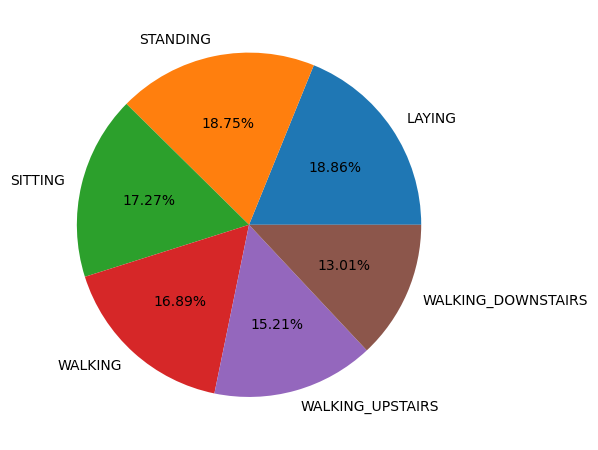

In [51]:
plt.figure(figsize=(6, 6))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index.map(activity_label_dict)
)
plt.tight_layout()

### Step 5: Model Development

#### Build Model

In [53]:
inputs = layers.Input((N_TIMESTEPS, N_FEATURES))
x = layers.LSTM(64, return_sequences=True)(inputs)
x = layers.LSTM(64)(x)
output = layers.Dense(N_CLASSES, activation='softmax')(x)

In [54]:
model = Model(inputs, output)

In [55]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 9)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 128, 64)             │          18,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,358 (204.52 KB)

 Trainable params: 52,358 (204.52 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile Model

In [56]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [57]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [58]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [59]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=0
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_value, y_value),
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 653ms/step - accuracy: 0.2668 - loss: 1.7321 - val_accuracy: 0.3995 - val_loss: 1.6204 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step - accuracy: 0.4310 - loss: 1.5513 - val_accuracy: 0.4186 - val_loss: 1.4031 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 585ms/step - accuracy: 0.4273 - loss: 1.3641 - val_accuracy: 0.4468 - val_loss: 1.3107 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 627ms/step - accuracy: 0.4659 - loss: 1.2731 - val_accuracy: 0.4951 - val_loss: 1.1621 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 627ms/step - accuracy: 0.5282 - loss: 1.1327 - val_accuracy: 0.5236 - val_loss: 1.0887 - learning_rate: 0.0010
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 569ms/step - accuracy: 0.5253 - loss: 1.0858 - val_accuracy: 0.5556 - val_loss: 1.0267 - learning_rate: 0.0010
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 725ms/step - accuracy: 0.5430 - loss: 1.0308 - val_accuracy: 

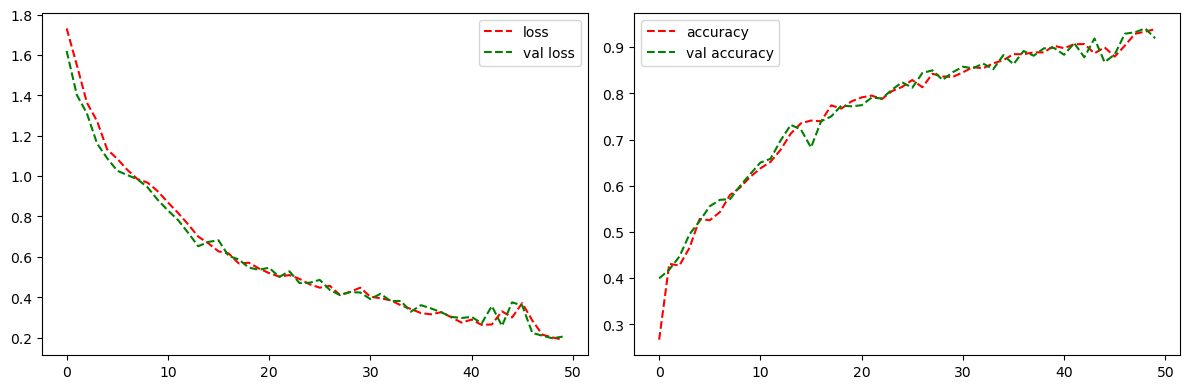

In [67]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'r--', label='loss')
plt.plot(history.history['val_loss'], 'g--', label='val loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'r--', label='accuracy')
plt.plot(history.history['val_accuracy'], 'g--', label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [68]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(acc, 3)}')

test loss: 0.481, test accuracy: 0.86


In [73]:
test_pred = model.predict(X_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


In [76]:
test_pred = np.argmax(test_pred, axis=-1)

In [79]:
confusion_matrix = metrics.confusion_matrix(y_test, test_pred)

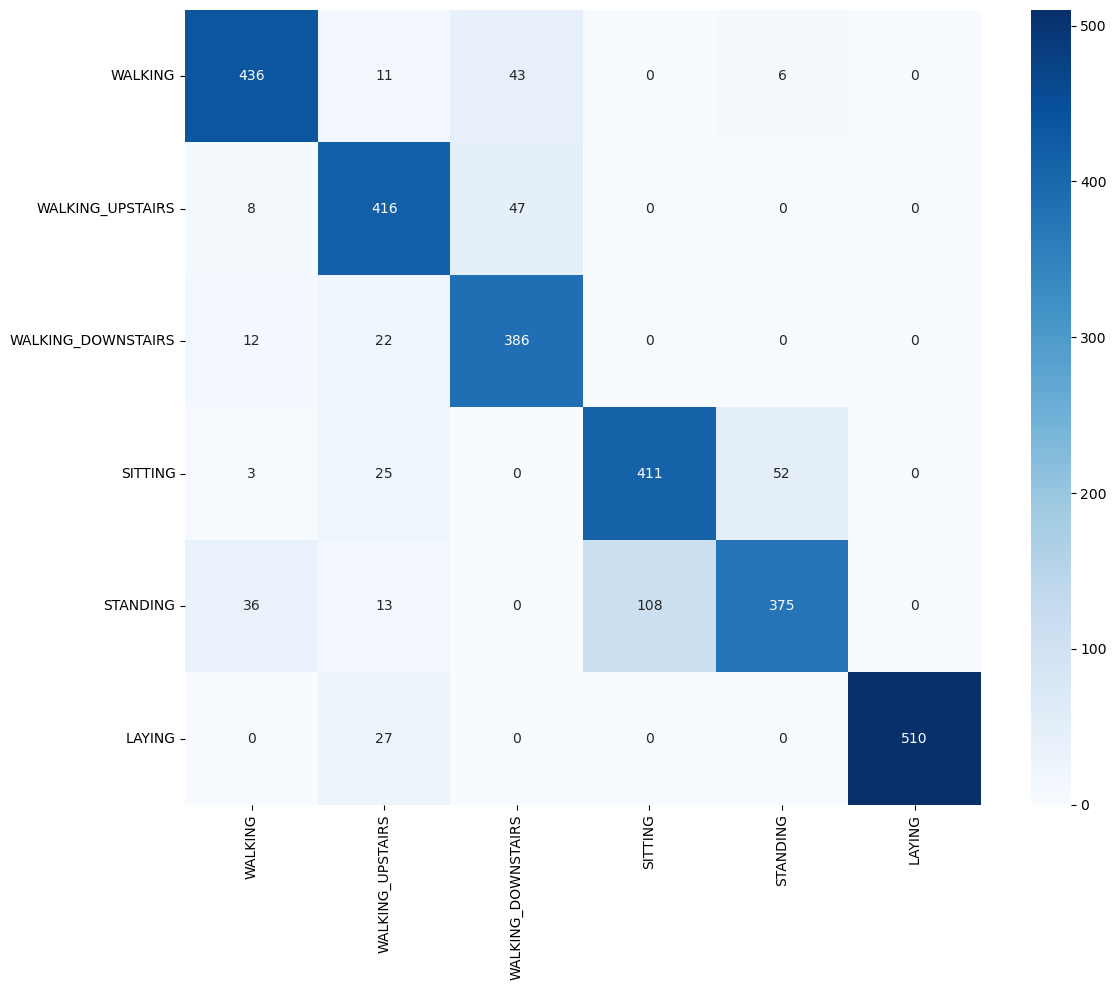

In [87]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues,
    xticklabels=activity_label_dict.values(),
    yticklabels=activity_label_dict.values()
)
plt.tight_layout()

In [89]:
print(metrics.classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       496
           1       0.81      0.88      0.84       471
           2       0.81      0.92      0.86       420
           3       0.79      0.84      0.81       491
           4       0.87      0.70      0.78       532
           5       1.00      0.95      0.97       537

    accuracy                           0.86      2947
   macro avg       0.86      0.86      0.86      2947
weighted avg       0.86      0.86      0.86      2947

